**01_data_inventory.ipynb**
+ application_train analizi
+ target dağılımı
+ eksik değer analizi
+ ilk feature'ların doğrulanması

In [1]:
import sys
from pathlib import Path

project_root = Path.cwd().parent
sys.path.append(str(project_root))

print(project_root)

c:\Users\ASUS\creditguard-ai


In [2]:
import pandas as pd

In [3]:
train = pd.read_csv("../data/raw/application_train.csv")
test = pd.read_csv("../data/raw/application_test.csv")

print(train.shape)
print(test.shape)

(307511, 122)
(48744, 121)


In [4]:
train.head()

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0


In [5]:
train.info()

<class 'pandas.DataFrame'>
RangeIndex: 307511 entries, 0 to 307510
Columns: 122 entries, SK_ID_CURR to AMT_REQ_CREDIT_BUREAU_YEAR
dtypes: float64(65), int64(41), str(16)
memory usage: 286.2 MB


In [6]:
train["TARGET"].value_counts(normalize=True)

TARGET
0    0.919271
1    0.080729
Name: proportion, dtype: float64

**Imbalanced Binary Classification**

In [7]:
train.columns.tolist()

['SK_ID_CURR',
 'TARGET',
 'NAME_CONTRACT_TYPE',
 'CODE_GENDER',
 'FLAG_OWN_CAR',
 'FLAG_OWN_REALTY',
 'CNT_CHILDREN',
 'AMT_INCOME_TOTAL',
 'AMT_CREDIT',
 'AMT_ANNUITY',
 'AMT_GOODS_PRICE',
 'NAME_TYPE_SUITE',
 'NAME_INCOME_TYPE',
 'NAME_EDUCATION_TYPE',
 'NAME_FAMILY_STATUS',
 'NAME_HOUSING_TYPE',
 'REGION_POPULATION_RELATIVE',
 'DAYS_BIRTH',
 'DAYS_EMPLOYED',
 'DAYS_REGISTRATION',
 'DAYS_ID_PUBLISH',
 'OWN_CAR_AGE',
 'FLAG_MOBIL',
 'FLAG_EMP_PHONE',
 'FLAG_WORK_PHONE',
 'FLAG_CONT_MOBILE',
 'FLAG_PHONE',
 'FLAG_EMAIL',
 'OCCUPATION_TYPE',
 'CNT_FAM_MEMBERS',
 'REGION_RATING_CLIENT',
 'REGION_RATING_CLIENT_W_CITY',
 'WEEKDAY_APPR_PROCESS_START',
 'HOUR_APPR_PROCESS_START',
 'REG_REGION_NOT_LIVE_REGION',
 'REG_REGION_NOT_WORK_REGION',
 'LIVE_REGION_NOT_WORK_REGION',
 'REG_CITY_NOT_LIVE_CITY',
 'REG_CITY_NOT_WORK_CITY',
 'LIVE_CITY_NOT_WORK_CITY',
 'ORGANIZATION_TYPE',
 'EXT_SOURCE_1',
 'EXT_SOURCE_2',
 'EXT_SOURCE_3',
 'APARTMENTS_AVG',
 'BASEMENTAREA_AVG',
 'YEARS_BEGINEXPLUATATION_A

In [8]:
pd.DataFrame({
    "column": train.columns,
    "dtype": train.dtypes.values,
    "missing": train.isnull().sum().values,
    "missing_pct": (train.isnull().mean()*100).values
}).sort_values("missing_pct", ascending=False)

,column,dtype,missing,missing_pct
48,COMMONAREA_AVG,float64,214865,69.872297
62,COMMONAREA_MODE,float64,214865,69.872297
76,COMMONAREA_MEDI,float64,214865,69.872297
84,NONLIVINGAPARTMENTS_MEDI,float64,213514,69.432963
70,NONLIVINGAPARTMENTS_MODE,float64,213514,69.432963
...,...,...,...,...
110,FLAG_DOCUMENT_16,int64,0,0.000000
109,FLAG_DOCUMENT_15,int64,0,0.000000
108,FLAG_DOCUMENT_14,int64,0,0.000000
114,FLAG_DOCUMENT_20,int64,0,0.000000


In [9]:
categorical_cols = train.select_dtypes(include="object").columns.tolist()

numeric_cols = train.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

print("Categorical:", len(categorical_cols))
print("Numeric:", len(numeric_cols))

Categorical: 16
Numeric: 106


C:\Users\ASUS\AppData\Local\Temp\ipykernel_11096\2486026569.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = train.select_dtypes(include="object").columns.tolist()


In [10]:
missing_df = pd.DataFrame({
    "column": train.columns,
    "missing_pct": train.isnull().mean()*100
})

missing_df = missing_df.sort_values(
    "missing_pct",
    ascending=False
)

missing_df.head(20)

,column,missing_pct
COMMONAREA_AVG,COMMONAREA_AVG,69.872297
COMMONAREA_MODE,COMMONAREA_MODE,69.872297
COMMONAREA_MEDI,COMMONAREA_MEDI,69.872297
NONLIVINGAPARTMENTS_MEDI,NONLIVINGAPARTMENTS_MEDI,69.432963
NONLIVINGAPARTMENTS_MODE,NONLIVINGAPARTMENTS_MODE,69.432963
NONLIVINGAPARTMENTS_AVG,NONLIVINGAPARTMENTS_AVG,69.432963
FONDKAPREMONT_MODE,FONDKAPREMONT_MODE,68.386172
LIVINGAPARTMENTS_AVG,LIVINGAPARTMENTS_AVG,68.354953
LIVINGAPARTMENTS_MEDI,LIVINGAPARTMENTS_MEDI,68.354953
LIVINGAPARTMENTS_MODE,LIVINGAPARTMENTS_MODE,68.354953


In [11]:
risk_cols = [
    "AMT_INCOME_TOTAL",
    "AMT_CREDIT",
    "AMT_ANNUITY",
    "DAYS_BIRTH",
    "DAYS_EMPLOYED"
]

train[risk_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
AMT_INCOME_TOTAL,307511.0,168797.919297,237123.146279,25650.0,112500.0,147150.0,202500.0,117000000.0
AMT_CREDIT,307511.0,599025.999706,402490.776996,45000.0,270000.0,513531.0,808650.0,4050000.0
AMT_ANNUITY,307499.0,27108.573909,14493.737315,1615.5,16524.0,24903.0,34596.0,258025.5
DAYS_BIRTH,307511.0,-16036.995067,4363.988632,-25229.0,-19682.0,-15750.0,-12413.0,-7489.0
DAYS_EMPLOYED,307511.0,63815.045904,141275.766519,-17912.0,-2760.0,-1213.0,-289.0,365243.0


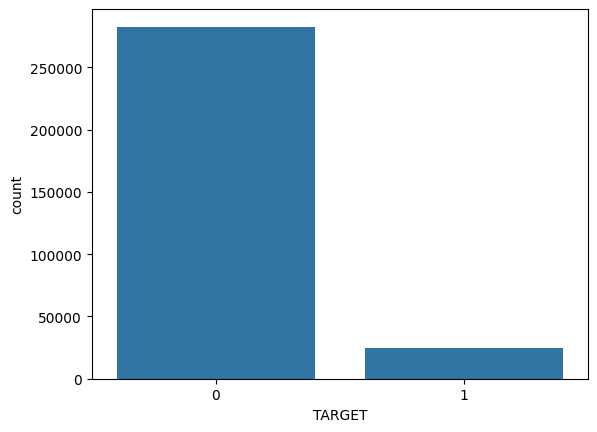

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.countplot(x="TARGET", data=train)

plt.show()

In [13]:
#Cinsiyet ve Temerrüt
pd.crosstab(
    train["CODE_GENDER"],
    train["TARGET"],
    normalize="index"
)

TARGET,0,1
CODE_GENDER,,
F,0.930007,0.069993
M,0.898581,0.101419
XNA,1.000000,0.000000


**Erkeklerde temerrüt oranı**
≈ %45 daha yüksek

In [14]:
#Ev Sahipliği ve Temerrüt
pd.crosstab(
    train["FLAG_OWN_REALTY"],
    train["TARGET"],
    normalize="index"
)

TARGET,0,1
FLAG_OWN_REALTY,,
N,0.916751,0.083249
Y,0.920384,0.079616


In [15]:
#Araç Sahipliği ve Temerrüt
pd.crosstab(
    train["FLAG_OWN_CAR"],
    train["TARGET"],
    normalize="index"
)

TARGET,0,1
FLAG_OWN_CAR,,
N,0.914998,0.085002
Y,0.927563,0.072437


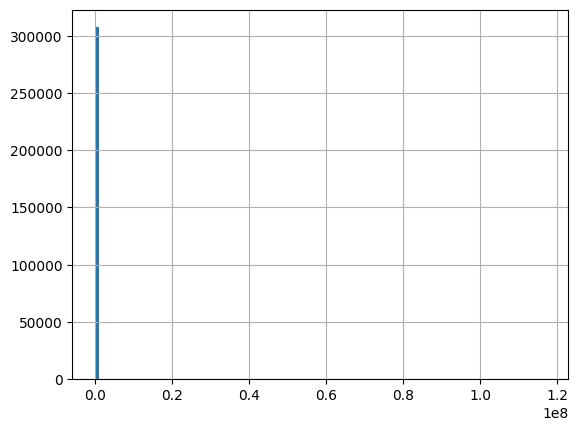

In [16]:
#Gelir Dağılımı
train["AMT_INCOME_TOTAL"].hist(
    bins=100
)
plt.show()

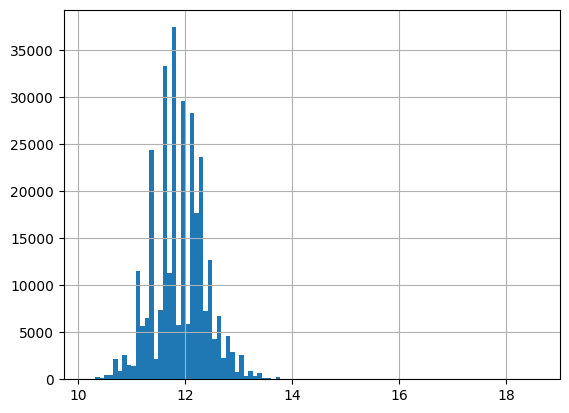

In [17]:
#Log Gelir Dağılımı
import numpy as np

np.log1p(
    train["AMT_INCOME_TOTAL"]
).hist(bins=100)

plt.show()

In [18]:
from src.features.build_features import create_features

In [19]:
featured_df = create_features(train)

In [20]:
featured_df[
    [
        "credit_income_ratio",
        "annuity_income_ratio",
        "credit_term",
        "age_years",
        "employment_years",
        "employment_age_ratio"
    ]
].head()

,credit_income_ratio,annuity_income_ratio,credit_term,age_years,employment_years,employment_age_ratio
0,2.007889,0.121978,16.461104,25.920548,1.745205,0.067329
1,4.790750,0.132217,36.234085,45.931507,3.254795,0.070862
2,2.000000,0.100000,20.000000,52.180822,0.616438,0.011814
3,2.316167,0.219900,10.532818,52.068493,8.326027,0.159905
4,4.222222,0.179963,23.461618,54.608219,8.323288,0.152418


In [1]:
import pandas as pd

df = pd.read_parquet(
    "../data/processed/train_features.parquet"
)

print(df.shape)

(307511, 136)


In [2]:
df.columns[-15:].tolist()

['AMT_REQ_CREDIT_BUREAU_YEAR',
 'credit_income_ratio',
 'annuity_income_ratio',
 'credit_term',
 'age_years',
 'employment_years',
 'employment_age_ratio',
 'income_per_family_member',
 'child_ratio',
 'credit_per_child',
 'income_credit_difference',
 'annuity_credit_ratio',
 'is_car_owner',
 'is_realty_owner',
 'is_employed']

In [1]:
import numpy as np
import pandas as pd
import pyarrow as pa

print(np.__version__)
print(pd.__version__)
print(pa.__version__)

1.26.4
2.2.2
15.0.2
